# Exploratory Data Analysis 

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

In [3]:
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('../Dataset/Telco_Customer_Churn_Cleaned.csv')

In [5]:
df.describe()

,tenure,monthly_charges,total_charges,expected_charges,diff_charges,total_services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2279.581350,0.152953,4.146244
std,24.559481,30.090047,2266.794470,2264.729447,67.202778,2.312720
min,0.000000,18.250000,0.000000,0.000000,-370.850000,1.000000
25%,9.000000,35.500000,398.550000,394.000000,-28.600000,2.000000
50%,29.000000,70.350000,1394.550000,1393.600000,0.000000,4.000000
75%,55.000000,89.850000,3786.600000,3786.100000,28.500000,6.000000
max,72.000000,118.750000,8684.800000,8550.000000,373.250000,9.000000


### Total Churn 

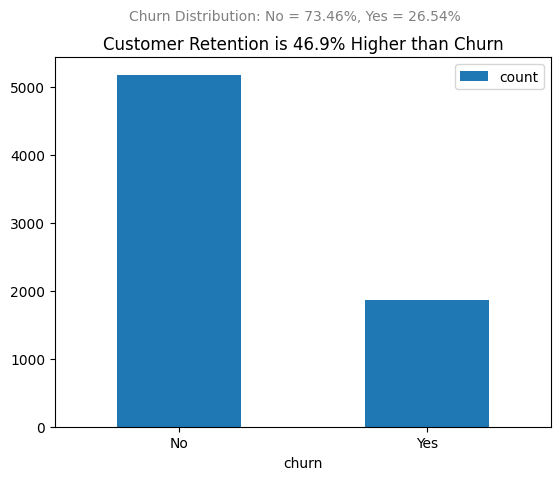

In [7]:
churn_counts = df.groupby(df['churn'])['customer_id'].count().reset_index(name='count')
churn_counts['percentage'] = (churn_counts['count']/churn_counts['count'].sum()*100).round(2)
diff_percentage = (churn_counts['percentage'][0] - churn_counts['percentage'][1]).round(1)

#visualize
churn_counts.plot(kind='bar', x='churn', y='count')
plt.xticks(rotation=0)
plt.title(f'Customer Retention is {diff_percentage}% Higher than Churn')
plt.suptitle(f"Churn Distribution: No = {churn_counts['percentage'][0]}%, Yes = {churn_counts['percentage'][1]}%", 
             fontsize=10, color="gray")
plt.show()

### Total Charges Contributed by Churned Customers

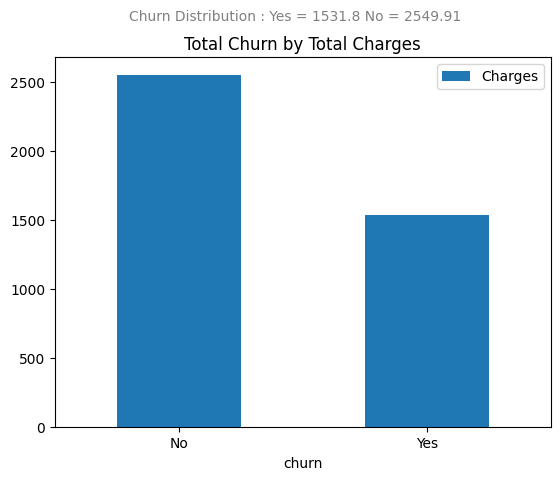

In [16]:
total_churn_by_total_charges = df.groupby('churn')['total_charges'].mean().reset_index(name='Charges')
no_churn_total_charges = (total_churn_by_total_charges.loc[total_churn_by_total_charges['churn'] == 'No', 'Charges'].values[0]).round(2)
churn_total_charges = (total_churn_by_total_charges.loc[total_churn_by_total_charges['churn'] == 'Yes', 'Charges'].values[0]).round(2)

total_churn_by_total_charges.plot(kind='bar', x='churn', y='Charges')
plt.title('Total Churn by Total Charges')
plt.suptitle(f"Churn Distribution : Yes = {churn_total_charges} No = {no_churn_total_charges}", fontsize=10, color="gray")
plt.xticks(rotation=0)
plt.show()

### Differention Charges Distribution

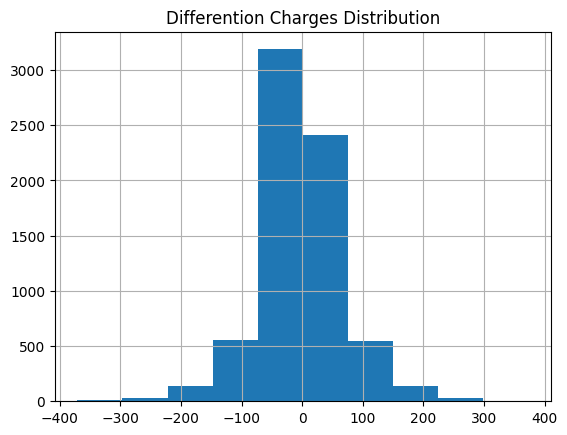

In [10]:
df['diff_charges'].hist()
plt.title('Differention Charges Distribution')
plt.show()

### Total Churn by Gap Charges

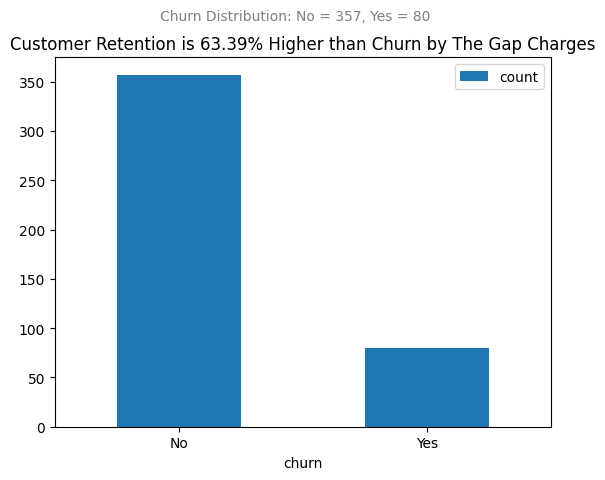

In [175]:
diff_charges_churn = df[df['diff_charges']<-100].groupby('churn')['customer_id'].count().reset_index(name='count')
count_no = diff_charges_churn.loc[diff_charges_churn['churn'] == 'No', 'count'].values[0]
count_yes = diff_charges_churn.loc[diff_charges_churn['churn'] == 'Yes', 'count'].values[0]
total = sum(diff_charges_churn['count'])
charge_percentage_diff = ((count_no-count_yes)/total*100).round(2)

#visualize 
diff_charges_churn.plot(kind='bar', x='churn', y='count')
plt.xticks(rotation=0)
plt.title(f'Customer Retention is {charge_percentage_diff}% Higher than Churn by The Gap Charges')
plt.suptitle(f"Churn Distribution: No = {count_no}, Yes = {count_yes}", 
             fontsize=10, color="gray")
plt.show()

### Total Churn by Monthly Charges

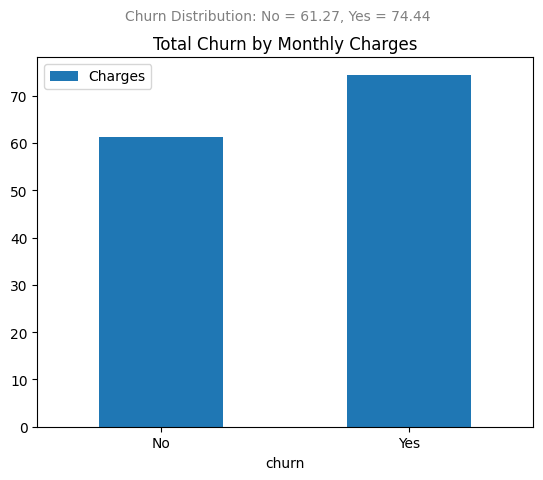

In [15]:
total_churn_by_monthly_charges = df.groupby('churn')['monthly_charges'].mean().reset_index(name='Charges')
no_churn_monthly_charges = (total_churn_by_monthly_charges.loc[total_churn_by_monthly_charges['churn'] == 'No', 'Charges'].values[0]).round(2)
churn_monthly_charges = (total_churn_by_monthly_charges.loc[total_churn_by_monthly_charges['churn'] == 'Yes', 'Charges'].values[0]).round(2)

total_churn_by_monthly_charges.plot(kind='bar', x='churn', y='Charges')
plt.title('Total Churn by Monthly Charges')
plt.suptitle(f"Churn Distribution: No = {no_churn_monthly_charges}, Yes = {churn_monthly_charges}", 
             fontsize=10, color="gray")
plt.xticks(rotation=0)
plt.show()

### Total Churn by Tenure

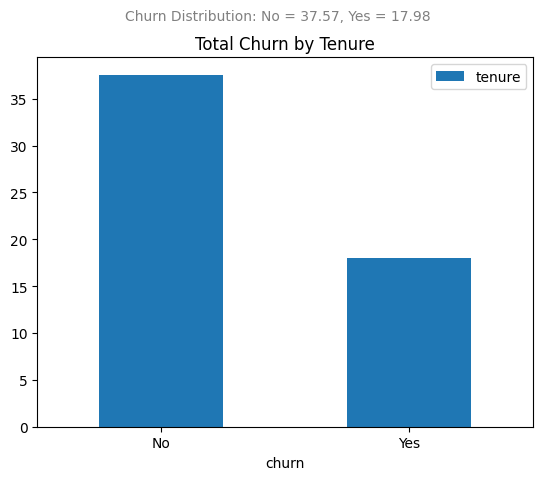

In [20]:
churn_by_tenure = df.groupby('churn')['tenure'].mean().reset_index(name='tenure')
no_churn_tenure = (churn_by_tenure.loc[churn_by_tenure['churn'] == 'No', 'tenure'].values[0]).round(2)
churn_tenure = (churn_by_tenure.loc[churn_by_tenure['churn'] == 'Yes', 'tenure'].values[0]).round(2)

churn_by_tenure.plot(kind='bar', x='churn', y='tenure')
plt.xticks(rotation=0)
plt.title('Total Churn by Tenure')
plt.suptitle(f"Churn Distribution: No = {no_churn_tenure}, Yes = {churn_tenure}", fontsize=10, color="gray")
plt.show()

### Total Churn by Contract

In [31]:
churn = df[df['churn'] == 'Yes']
retention = df[df['churn'] == 'No']

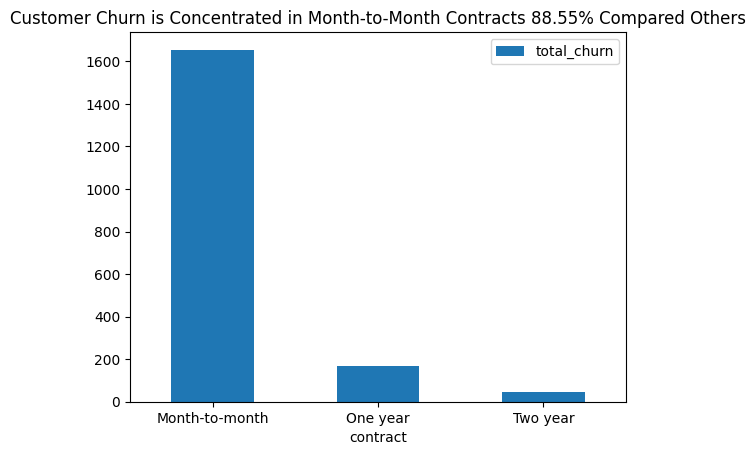

In [14]:
churn_by_contract = churn.groupby('contract')['customer_id'].count().reset_index(name = 'total_churn')
churn_by_contract['percentage'] = (churn_by_contract['total_churn']/sum(churn_by_contract['total_churn']) * 100).round(2)
churn_by_contract.plot(kind='bar', x='contract', y='total_churn')
plt.title(f"Customer Churn is Concentrated in Month-to-Month Contracts {max(churn_by_contract['percentage'])}% Compared Others")
plt.xticks(rotation = 0)
plt.show()

### Churn Tenure for Month to Month Contracts

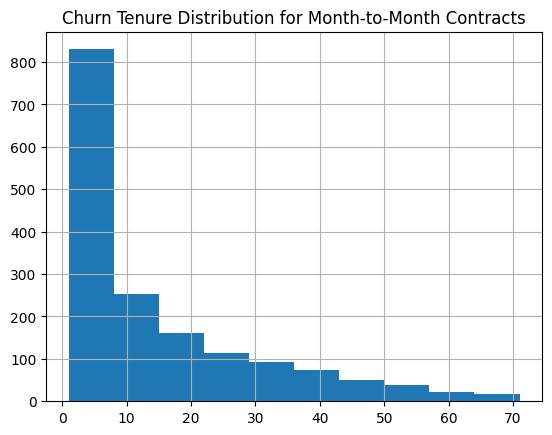

In [19]:
churn[churn['contract'] == 'Month-to-month']['tenure'].hist()
plt.title('Churn Tenure Distribution for Month-to-Month Contracts')
plt.show()

### Total Services for Churn and Retention

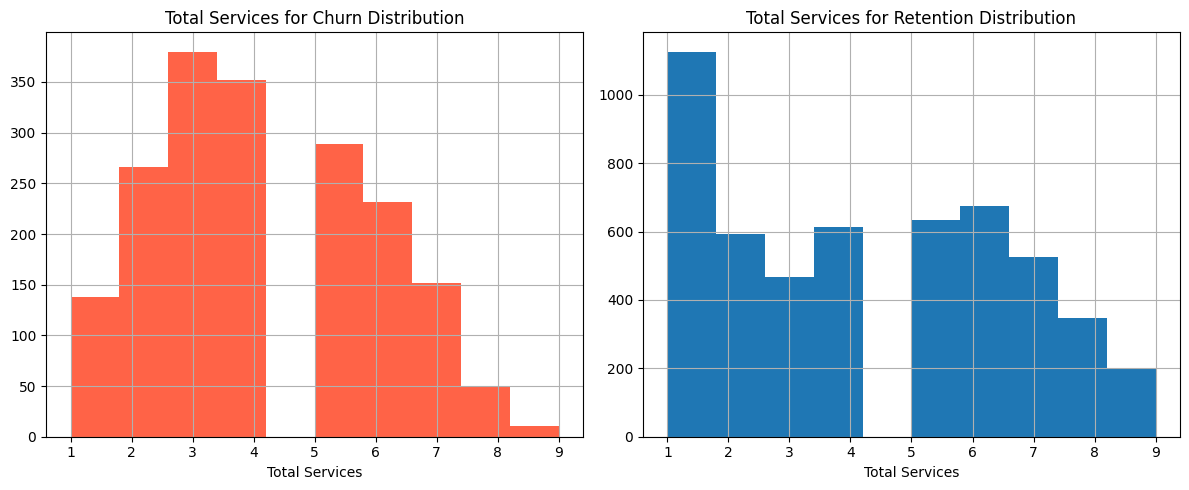

In [35]:
fig, axes = plt.subplots(1,2, figsize=(12,5))


churn['total_services'].hist(ax=axes[0],color='tomato')
axes[0].set_title('Total Services for Churn Distribution')
axes[0].set_xlabel('Total Services')

retention['total_services'].hist(ax=axes[1])
axes[1].set_title('Total Services for Retention Distribution')
axes[1].set_xlabel('Total Services')

plt.tight_layout()
plt.show()

### Total Churn by Services 

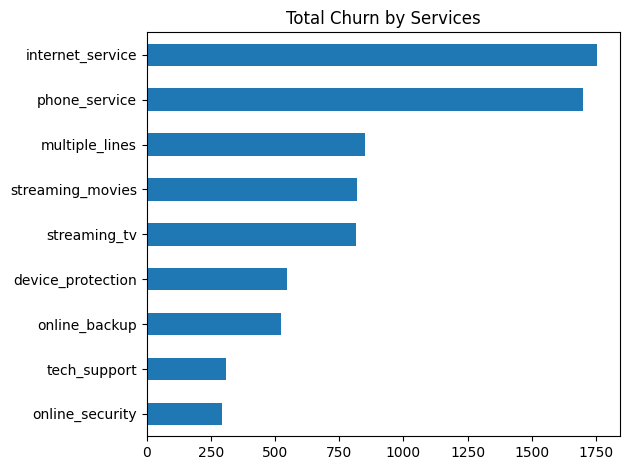

In [83]:
services_churn_numeric = churn[['phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']].replace({'Yes' : 1, 'No':0, 'DSL':1, 'Fiber optic':1})
services_churn_numeric.sum(axis=0).sort_values(ascending=False).plot(kind='barh', title='Total Churn by Services')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Total Retention by Services 

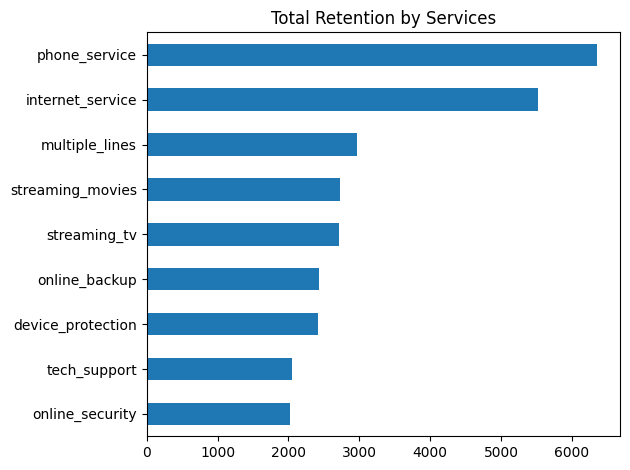

In [ ]:
services_retention_numeric = df[['phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']].replace({'Yes' : 1, 'No':0, 'DSL':1, 'Fiber optic':1})
services_retention_numeric.sum(axis=0).sort_values(ascending=False).plot(kind='barh', title='Total Retention by Services')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Total Churn by Internet Services Category

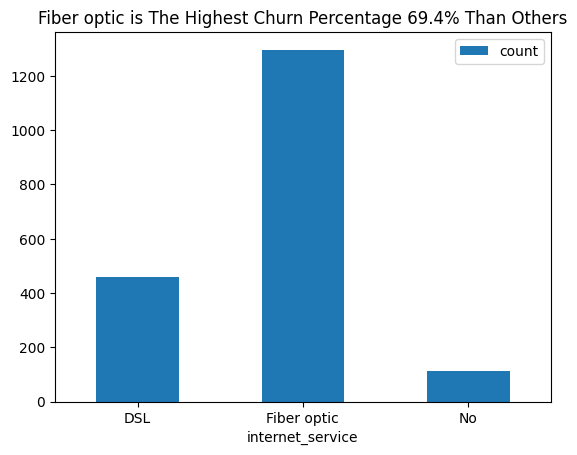

In [34]:
churn_by_internet_service = churn.groupby('internet_service')['customer_id'].count().reset_index(name = 'count')
churn_by_internet_service['percentage'] = (churn_by_internet_service['count']/sum(churn_by_internet_service['count'])*100).round(2)
churn_by_internet_service.plot(kind='bar', x='internet_service', y='count')
highest_row = churn_by_internet_service.loc[churn_by_internet_service['percentage'].idxmax()]
plt.title(f"{highest_row['internet_service']} is The Highest Churn Percentage {highest_row['percentage']}% Than Others")
plt.xticks(rotation=0)
plt.show()

### Total Retention by Internet Services Category

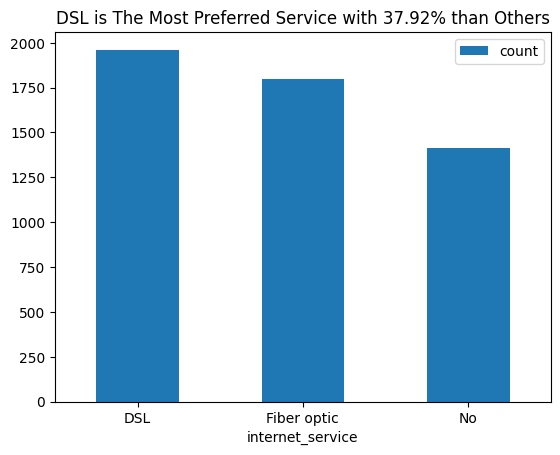

In [ ]:
retention_by_internet_service = retention.groupby('internet_service')['customer_id'].count().reset_index(name = 'count')
retention_by_internet_service['percentage'] = (retention_by_internet_service['count']/sum(retention_by_internet_service['count'])*100).round(2)
highest_row = retention_by_internet_service.loc[retention_by_internet_service['percentage'].idxmax()]
retention_by_internet_service.plot(kind='bar', x='internet_service', y='count')
plt.title(f"{highest_row['internet_service']} is The Most Preferred Service with {highest_row['percentage']}% than Others")
plt.xticks(rotation=0)
plt.show()

### Internet Services by Monthly Charges

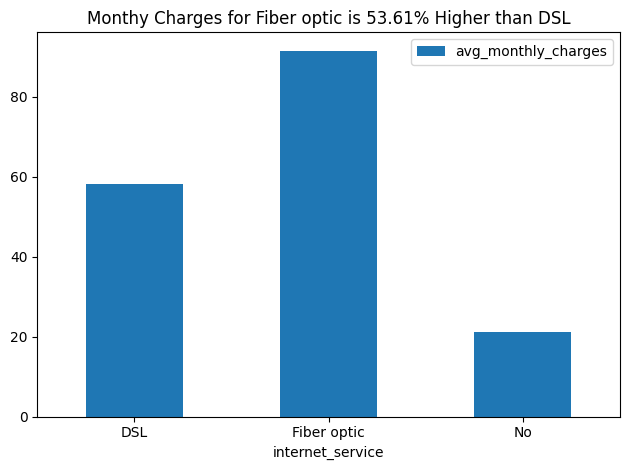

In [ ]:
internet_service_by_monthly_charges = df.groupby('internet_service')['monthly_charges'].mean().reset_index(name='avg_monthly_charges')
internet_service_by_monthly_charges['percentage'] = (internet_service_by_monthly_charges['avg_monthly_charges']/sum(internet_service_by_monthly_charges['avg_monthly_charges'])*100).round(2)
highest_row = internet_service_by_monthly_charges.iloc[internet_service_by_monthly_charges['percentage'].idxmax()]
internet_service_by_monthly_charges.plot(kind='bar', x='internet_service', y='avg_monthly_charges')
plt.title(f"Monthy Charges for {highest_row['internet_service']} is {highest_row['percentage']}% Higher than DSL")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Churned Internet Services by Add-on Services

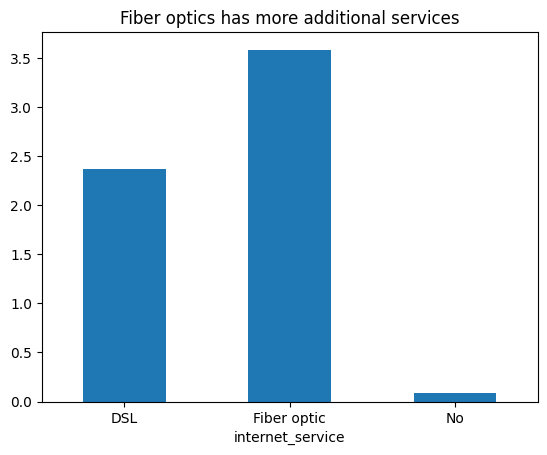

In [41]:
services_churn = churn[['internet_service', 'total_services']]
services_churn['total_services'] = services_churn['total_services']-1 
services_churn.groupby('internet_service')['total_services'].mean().plot(kind='bar')
plt.title('Fiber optics has more additional services')
plt.xticks(rotation=0)
plt.show()

### Add-on Services with Fiber Optic 

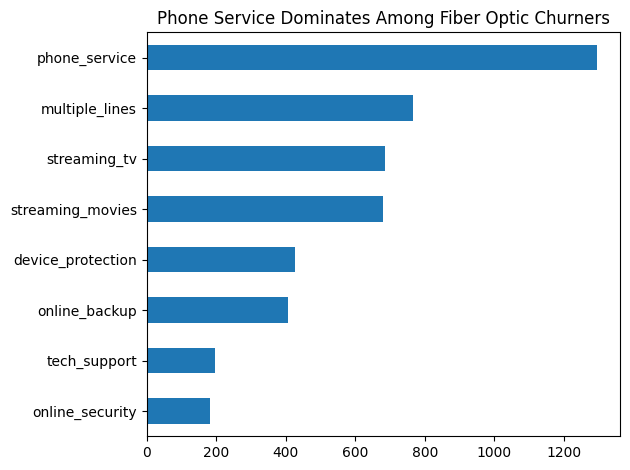

In [ ]:
churn_fiber_optic = churn[churn['internet_service'] == 'Fiber optic']
other_services = churn_fiber_optic[['phone_service', 'multiple_lines', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']]
other_services_numeric = other_services.replace({'Yes' : 1, 'No' : 0})
other_services_numeric.sum(axis=0).sort_values(ascending=False).plot(kind='barh')
plt.title('Phone Service Dominates Among Fiber Optic Churners')
plt.tight_layout()
plt.gca().invert_yaxis()

### Dependents Distribution by Tenure

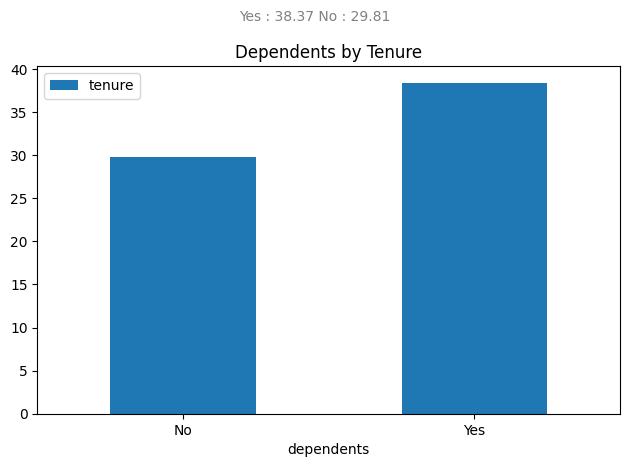

In [152]:
dependents_by_tenure = df.groupby('dependents')['tenure'].mean().reset_index(name='tenure')
dependents_by_tenure.plot(kind='bar', title='Dependents by Tenure', x='dependents', y='tenure')
yes_tenure = (dependents_by_tenure.loc[dependents_by_tenure['dependents'] == 'Yes', 'tenure'].values[0]).round(2)
no_tenure = (dependents_by_tenure.loc[dependents_by_tenure['dependents'] == 'No', 'tenure'].values[0]).round(2)
plt.suptitle(f"Yes : {yes_tenure} No : {no_tenure}", fontsize=10, color="gray")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### Dependents Distribution by Average Monthly Charges

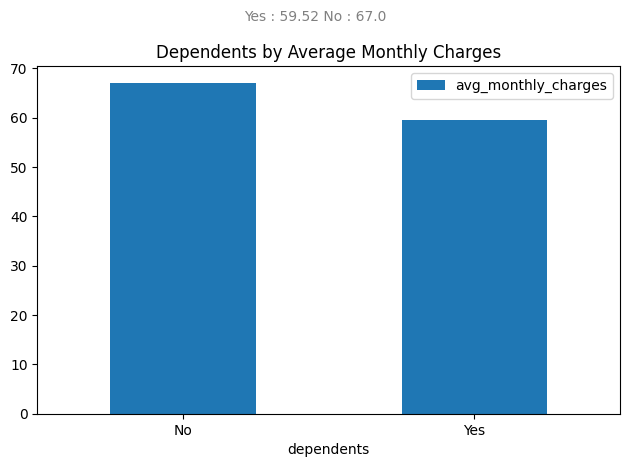

In [158]:
dependents_monthly_charges = df.groupby('dependents')['monthly_charges'].mean().reset_index(name='avg_monthly_charges')
yes_month_charges = (dependents_monthly_charges.loc[dependents_monthly_charges['dependents'] == 'Yes', 'avg_monthly_charges'].values[0]).round(2)
no_month_charges = (dependents_monthly_charges.loc[dependents_monthly_charges['dependents'] == 'No', 'avg_monthly_charges'].values[0]).round(2)
dependents_monthly_charges.plot(kind='bar', title='Dependents by Average Monthly Charges', x='dependents', y='avg_monthly_charges')
plt.suptitle(f"Yes : {yes_month_charges} No : {no_month_charges}", fontsize=10, color="gray")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### Internet Services Distribution by Dependents

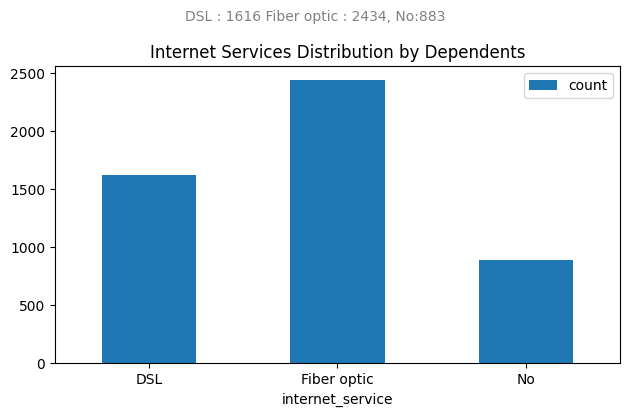

In [47]:
dependents_internet_services = df[df['dependents'] == 'No'].groupby('internet_service')['customer_id'].count().reset_index(name='count')
dsl_category = dependents_internet_services.loc[dependents_internet_services['internet_service'] == 'DSL', 'count'].values[0]
fiber_category = dependents_internet_services.loc[dependents_internet_services['internet_service'] == 'Fiber optic', 'count'].values[0]
no_category = dependents_internet_services.loc[dependents_internet_services['internet_service'] == 'No', 'count'].values[0]
dependents_internet_services.plot(kind='bar', title='Internet Services Distribution by Dependents', x='internet_service', y='count')
plt.suptitle(f"DSL : {dsl_category} Fiber optic : {fiber_category}, No:{no_category}", fontsize=10, color='gray')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### Dependents Distribution by Total Churn

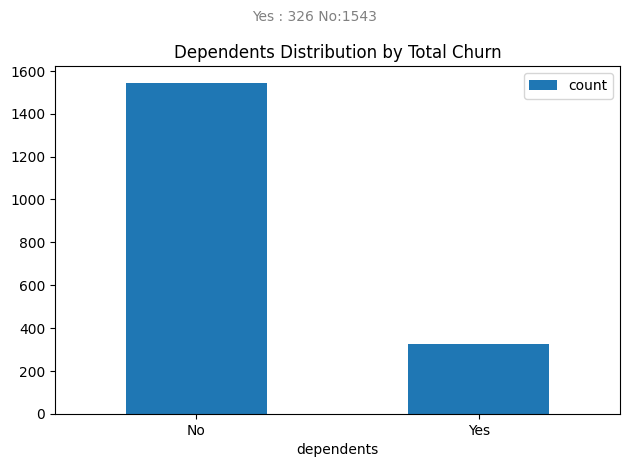

In [165]:
churn_dependents = churn.groupby('dependents')['customer_id'].count().reset_index(name='count')
yes_category = churn_dependents.loc[churn_dependents['dependents'] == 'Yes', 'count'].values[0]
no_category = churn_dependents.loc[churn_dependents['dependents'] == 'No', 'count'].values[0]

churn_dependents.plot(kind='bar', title='Dependents Distribution by Total Churn', x='dependents', y='count')
plt.suptitle(f"Yes : {yes_category} No:{no_category}", fontsize=10, color='gray')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()


### Dependents Distribution by Average Services

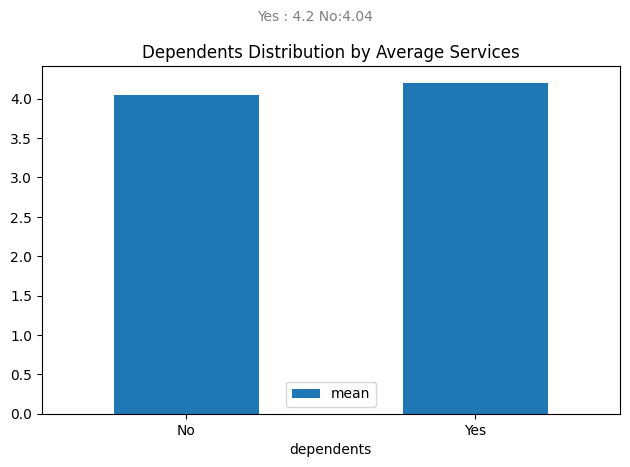

In [ ]:
dependents_mean_services = churn.groupby('dependents')['total_services'].mean().reset_index(name='mean')
yes_category = (dependents_mean_services.loc[dependents_mean_services['dependents'] == 'Yes', 'mean'].values[0]).round(2)
no_category = (dependents_mean_services.loc[dependents_mean_services['dependents'] == 'No', 'mean'].values[0]).round(2)

dependents_mean_services.plot(kind='bar', title='Dependents Distribution by Average Services', x='dependents', y='mean')
plt.suptitle(f"Yes : {yes_category} No:{no_category}", fontsize=10, color='gray')
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### Independents Churn Services

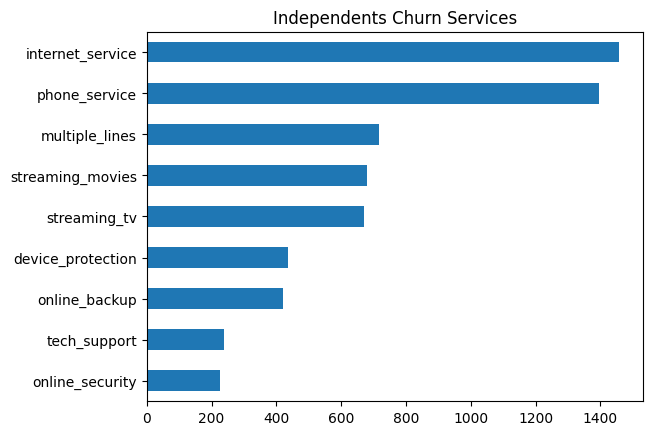

In [167]:
independents_churn_services = churn[churn['dependents'] == 'No'][['phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']].replace({'Yes' : 1, 'No':0, 'DSL':1, 'Fiber optic':1}).sum(axis=0)
independents_churn_services.sort_values(ascending=False).plot(kind='barh')
plt.title(f'Independents Churn Services')
plt.gca().invert_yaxis()
plt.show()